In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
import pandas as pd
import json
import os
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import random
from PIL import Image
from torch.utils.data import Dataset
from typing import Tuple, Dict, List
import torch
from torchvision import transforms
import torchvision.models as models
from timeit import default_timer as timer
from sklearn.model_selection import KFold
from tqdm.auto import tqdm
from transformers import BertModel, BertTokenizer, ViTModel

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/hateful_memes/shuffled_training_data.csv')

In [ ]:
df

,id,img,label,text
0,93072,img/93072.png,1,"black people black people ""why would white ame..."
1,90638,img/90638.png,0,i think it's great when women succeed at work ...
2,20957,img/20957.png,0,jew haters demonrat sewage an evil cancer that...
3,31278,img/31278.png,1,"it's not a hijab it's a diaper, for peoples wi..."
4,79368,img/79368.png,1,how do you start a rave in ethiopia tape a pei...
...,...,...,...,...
10995,75023,img/75023.png,1,"shoot boy, i ain't racist i've got four black ..."
10996,38509,img/38509.png,0,1947 something went... 2017... terribly right
10997,28096,img/28096.png,0,this is for all you nosey fuckers that only fo...
10998,81720,img/81720.png,0,let's go! staring contest!


In [ ]:
all_ids = df['id'].tolist()

In [ ]:
all_ids[:10]

[93072, 90638, 20957, 31278, 79368, 40125, 43907, 97502, 56189, 67852250]

In [ ]:
images_dict = {}
for i in range(len(df)):
  img = df.loc[df['id'] == all_ids[i]].iloc[0]['img']
  images_dict[all_ids[i]] = img

In [ ]:
text_dict = {}
for i in range(len(df)):
  text = df.loc[df['id'] == all_ids[i]].iloc[0]['text']
  text_dict[all_ids[i]] = text

In [ ]:
directory2 = '/content/drive/MyDrive/hateful_memes/'

In [ ]:
labels = df['label'].tolist()

In [ ]:
checkpoint_path = '/content/drive/MyDrive/hateful_memes/checkpoint.pth'

In [ ]:
len(labels)

11000

In [ ]:
import torch
import torch.nn as nn
import torchvision
from torchvision import transforms
from torch.utils.data import DataLoader, Dataset
from sklearn.metrics import accuracy_score, roc_auc_score
from tqdm import tqdm
from PIL import Image
import os

# Check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [ ]:
# Custom dataset class
class CustomDataset(Dataset):
    def __init__(self, image_dict, text_dict, tokenizer, max_length, labels, transform=None):
        self.image_dict = image_dict
        self.text_dict = text_dict
        self.tokenizer = tokenizer
        self.max_length = max_length
        self.transform = transform
        self.labels = labels
        self.image_ids = list(image_dict.keys())

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx):
        image_id = self.image_ids[idx]
        img_path = self.image_dict[image_id]
        image = Image.open(directory2 + img_path).convert('RGB')
        text = self.text_dict[image_id]
        label = self.labels[idx]
        encoding = self.tokenizer.encode_plus(
            text,
            add_special_tokens=True,
            max_length=self.max_length,
            return_tensors='pt',
            padding='max_length',
            truncation=True
        )
        input_ids = encoding['input_ids'].squeeze()
        attention_mask = encoding['attention_mask'].squeeze()
        if self.transform:
            image = self.transform(image)
        return image, input_ids, attention_mask, torch.tensor(label, dtype=torch.long)

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [ ]:
from transformers import BertTokenizer

# Assume text_dict is already defined
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

def get_max_length(text_dict, tokenizer):
    max_length = 0
    for text in text_dict.values():
        tokens = tokenizer.encode(text, add_special_tokens=True)
        max_length = max(max_length, len(tokens))
    return max_length

max_length = get_max_length(text_dict, tokenizer)
print(f"Determined max_length: {max_length}")

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:89: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

/usr/local/lib/python3.10/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


Determined max_length: 88


In [ ]:
dataset = CustomDataset(images_dict, text_dict, tokenizer, max_length=max_length, labels=labels, transform=transform)

train_size = int(0.7 * len(dataset))
val_size = int(0.1 * len(dataset))
test_size = len(dataset) - train_size - val_size
train_dataset, val_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_size, val_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=8, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=16, pin_memory=True,shuffle=False)

In [ ]:
import torch
import torch.nn as nn
from transformers import BertModel, ViTModel, AutoModel

class CrossModalAttention(nn.Module):
    def __init__(self, embed_dim, num_heads):
        super(CrossModalAttention, self).__init__()
        # Multihead attention for cross-modal interaction
        self.cross_attn = nn.MultiheadAttention(embed_dim=embed_dim, num_heads=num_heads)

    def forward(self, query, key, value):
        # Apply cross-attention (text -> image or image -> text)
        attn_output, _ = self.cross_attn(query=query, key=key, value=value)
        return attn_output

In [ ]:
import torch
import torch.optim as optim
import torch.nn as nn
from transformers import BertModel, BertTokenizer, ViTModel

class HatefulMemesClassifierWithCrossAttention(nn.Module):
    def __init__(self, bert_model_name='bert-base-uncased', vit_model_name='google/vit-base-patch16-224'):
        super(HatefulMemesClassifierWithCrossAttention, self).__init__()

        # BERT model
        self.bert = BertModel.from_pretrained(bert_model_name)
        self.bert_fc1 = nn.Linear(768, 128)
        self.bert_fc2 = nn.Linear(128, 128)
        self.bert_dropout = nn.Dropout(0.3)

        # Vision Transformer (ViT) model
        self.vit = ViTModel.from_pretrained(vit_model_name)
        self.vit_fc1 = nn.Linear(768, 128)
        self.vit_fc2 = nn.Linear(128, 128)
        self.vit_dropout = nn.Dropout(0.3)

        # Cross-modality attention (BERT <--> ViT)
        self.text_to_image_attention = CrossModalAttention(embed_dim=128, num_heads=8)
        self.image_to_text_attention = CrossModalAttention(embed_dim=128, num_heads=8)

        # Classification head
        self.fusion_fc1 = nn.Linear(256, 64)
        self.fusion_fc2 = nn.Linear(64, 2)

    def forward(self, input_ids, attention_mask, pixel_values):
        # BERT forward pass
        bert_outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        bert_cls = bert_outputs.last_hidden_state[:, 0, :]  # CLS token
        bert_x = self.bert_dropout(bert_cls)
        bert_x = torch.relu(self.bert_fc1(bert_x))
        bert_x = torch.relu(self.bert_fc2(bert_x))

        # ViT forward pass
        vit_outputs = self.vit(pixel_values=pixel_values)
        vit_cls = vit_outputs.last_hidden_state[:, 0, :]  # CLS token for ViT
        vit_x = self.vit_dropout(vit_cls)
        vit_x = torch.relu(self.vit_fc1(vit_x))
        vit_x = torch.relu(self.vit_fc2(vit_x))

        # Text attending to image
        attn_text_to_image = self.text_to_image_attention(
            query=bert_x.unsqueeze(0),  # Query is text embeddings
            key=vit_x.unsqueeze(0),     # Key is image embeddings
            value=vit_x.unsqueeze(0)    # Value is image embeddings
        ).squeeze(0)

        # Image attending to text
        attn_image_to_text = self.image_to_text_attention(
            query=vit_x.unsqueeze(0),   # Query is image embeddings
            key=bert_x.unsqueeze(0),    # Key is text embeddings
            value=bert_x.unsqueeze(0)   # Value is text embeddings
        ).squeeze(0)

        # Combine the attended representations (e.g., by concatenation)
        combined = torch.cat((attn_text_to_image, attn_image_to_text), dim=1)

        # Fusion
        combined = torch.relu(self.fusion_fc1(combined))
        logits = self.fusion_fc2(combined)

        return logits

In [ ]:
from sklearn.metrics import classification_report, precision_recall_fscore_support
def save_model(model, save_dir=directory2, filename='final_model_with_attention_augmented.pth'):
    if not os.path.exists(save_dir):
        os.makedirs(save_dir)
    save_path = os.path.join(save_dir, filename)
    torch.save(model.state_dict(), save_path)
    print(f"Model saved to {save_path}")

def validate_model(model, dataloader, criterion, device='cuda'):
    model.to(device)
    model.eval()  # Set the model to evaluation mode
    running_loss = 0.0
    running_corrects = 0
    total_samples = 0

    all_labels = []
    all_preds = []

    with torch.no_grad():
        for images, input_ids, attention_mask, labels in tqdm(dataloader, desc='Validation'):
            images = images.to(device)
            input_ids = input_ids.to(device)
            attention_mask = attention_mask.to(device)
            labels = labels.to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask, pixel_values=images)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            total_samples += labels.size(0)

            _, preds = torch.max(outputs, dim=1)
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())

    # Calculate metrics
    precision, recall, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average='weighted')
    accuracy = sum(np.array(all_preds) == np.array(all_labels)) / total_samples

    # Generate the classification report
    class_report = classification_report(all_labels, all_preds)

    epoch_loss = running_loss / len(dataloader)
    print(f'Validation Loss: {epoch_loss:.4f} Accuracy: {accuracy:.4f} Precision: {precision:.4f} Recall: {recall:.4f} F1 Score: {f1:.4f}')
    print("\nClassification Report:\n", class_report)
    return epoch_loss, accuracy, precision, recall, f1, class_report

In [ ]:
model = HatefulMemesClassifierWithCrossAttention(
    bert_model_name='bert-base-uncased',  # or any BERT variant you prefer
    vit_model_name='google/vit-base-patch16-224'  # or other ViT variants
)

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/69.7k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Some weights of ViTModel were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized: ['vit.pooler.dense.bias', 'vit.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=2e-5)

In [ ]:
from sklearn.metrics import classification_report, precision_recall_fscore_support
import numpy as np
import torch
from tqdm import tqdm

def test_model(model, test_loader, criterion, device='cuda'):
    model.eval()  # Set the model to evaluation mode
    running_loss = 0.0
    total_samples = 0

    all_labels = []
    all_preds = []

    with torch.no_grad():
        for images, input_ids, attention_mask, labels in tqdm(test_loader, desc='Testing'):
            images = images.to(device)
            input_ids = input_ids.to(device)
            attention_mask = attention_mask.to(device)
            labels = labels.to(device)

            # Forward pass
            outputs = model(input_ids=input_ids, attention_mask=attention_mask, pixel_values=images)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            total_samples += labels.size(0)

            # Get predictions
            _, preds = torch.max(outputs, dim=1)
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())

    # Calculate weighted precision, recall, f1, and accuracy
    precision, recall, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average='weighted')
    accuracy = sum(np.array(all_preds) == np.array(all_labels)) / total_samples

    # Generate the classification report
    class_report = classification_report(all_labels, all_preds)

    epoch_loss = running_loss / len(test_loader)
    print(f'Test Loss: {epoch_loss:.4f} Accuracy: {accuracy:.4f} Precision: {precision:.4f} Recall: {recall:.4f} F1 Score: {f1:.4f}')
    print("\nClassification Report:\n", class_report)

    return epoch_loss, accuracy, precision, recall, f1, class_report

In [ ]:
import torch
from torch import nn, optim
from torch.utils.data import DataLoader
from tqdm import tqdm

def calculate_metrics(outputs, labels):
    _, preds = torch.max(outputs, dim=1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels.cpu().numpy(), preds.cpu().numpy(), average='weighted')
    accuracy = torch.sum(preds == labels).item() / len(labels)
    return accuracy, precision, recall, f1

def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=5, device='cuda'):
    model.to(device)  # Move model to the specified device

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        running_corrects = 0
        total_samples = 0

        all_labels = []
        all_preds = []

        # Create a progress bar with tqdm
        loop = tqdm(enumerate(train_loader), total=len(train_loader), leave=False)
        for i, (images, input_ids, attention_mask, labels) in loop:
            images = images.to(device)
            input_ids = input_ids.to(device)
            attention_mask = attention_mask.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(input_ids=input_ids, attention_mask=attention_mask, pixel_values=images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            total_samples += labels.size(0)

            _, preds = torch.max(outputs, dim=1)
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())

            # Update the progress bar with current loss and accuracy
            loop.set_description(f"Epoch [{epoch+1}/{num_epochs}]")
            loop.set_postfix(loss=running_loss / (i+1))

        # Calculate metrics
        precision, recall, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average='weighted')
        accuracy = sum(np.array(all_preds) == np.array(all_labels)) / total_samples

        # Generate the classification report
        class_report = classification_report(all_labels, all_preds)

        epoch_loss = running_loss / len(train_loader)
        print(f"Epoch [{epoch+1}/{num_epochs}] Training Loss: {epoch_loss:.4f} Accuracy: {accuracy:.4f} Precision: {precision:.4f} Recall: {recall:.4f} F1 Score: {f1:.4f}")
        print("\nClassification Report:\n", class_report)

        # Validate the model after each epoch
        validate_model(model, val_loader, criterion, device)

    # Save the model at the end of training
    save_model(model)
    print("Training complete!")

train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=5, device='cuda')

Epoch [1/5] Training Loss: 0.6160 Accuracy: 0.6779 Precision: 0.6863 Recall: 0.6779 F1 Score: 0.6751

Classification Report:
               precision    recall  f1-score   support

           0       0.64      0.77      0.70      3790
           1       0.73      0.58      0.65      3909

    accuracy                           0.68      7699
   macro avg       0.69      0.68      0.68      7699
weighted avg       0.69      0.68      0.68      7699



Validation: 100%|██████████| 138/138 [10:07<00:00,  4.40s/it]


Validation Loss: 0.4859 Accuracy: 0.7964 Precision: 0.7968 Recall: 0.7964 F1 Score: 0.7961

Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.83      0.81       566
           1       0.81      0.76      0.78       534

    accuracy                           0.80      1100
   macro avg       0.80      0.80      0.80      1100
weighted avg       0.80      0.80      0.80      1100



Epoch [2/5] Training Loss: 0.4180 Accuracy: 0.8149 Precision: 0.8160 Recall: 0.8149 F1 Score: 0.8149

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.84      0.82      3790
           1       0.84      0.79      0.81      3909

    accuracy                           0.81      7699
   macro avg       0.82      0.82      0.81      7699
weighted avg       0.82      0.81      0.81      7699



Validation: 100%|██████████| 138/138 [00:38<00:00,  3.55it/s]


...

Validation: 100%|██████████| 138/138 [00:36<00:00,  3.74it/s]


Validation Loss: 0.5072 Accuracy: 0.8173 Precision: 0.8221 Recall: 0.8173 F1 Score: 0.8170

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.77      0.81       566
           1       0.78      0.87      0.82       534

    accuracy                           0.82      1100
   macro avg       0.82      0.82      0.82      1100
weighted avg       0.82      0.82      0.82      1100



Epoch [5/5] Training Loss: 0.0761 Accuracy: 0.9762 Precision: 0.9762 Recall: 0.9762 F1 Score: 0.9762

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.98      0.98      3790
           1       0.98      0.97      0.98      3909

    accuracy                           0.98      7699
   macro avg       0.98      0.98      0.98      7699
weighted avg       0.98      0.98      0.98      7699



Validation: 100%|██████████| 138/138 [00:37<00:00,  3.68it/s]


Validation Loss: 0.5794 Accuracy: 0.8327 Precision: 0.8357 Recall: 0.8327 F1 Score: 0.8326

Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.80      0.83       566
           1       0.80      0.87      0.84       534

    accuracy                           0.83      1100
   macro avg       0.83      0.83      0.83      1100
weighted avg       0.84      0.83      0.83      1100

Model saved to /content/drive/MyDrive/hateful_memes/final_model_with_attention_augmented.pth
Training complete!


In [ ]:
test_loss, test_accuracy, test_precision, test_recall, test_f1, class_report = test_model(model, test_loader, criterion, device='cuda')

Testing: 100%|██████████| 138/138 [20:36<00:00,  8.96s/it]

Test Loss: 0.6744 Accuracy: 0.8024 Precision: 0.8043 Recall: 0.8024 F1 Score: 0.8023

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.77      0.80      1125
           1       0.78      0.84      0.81      1076

    accuracy                           0.80      2201
   macro avg       0.80      0.80      0.80      2201
weighted avg       0.80      0.80      0.80      2201



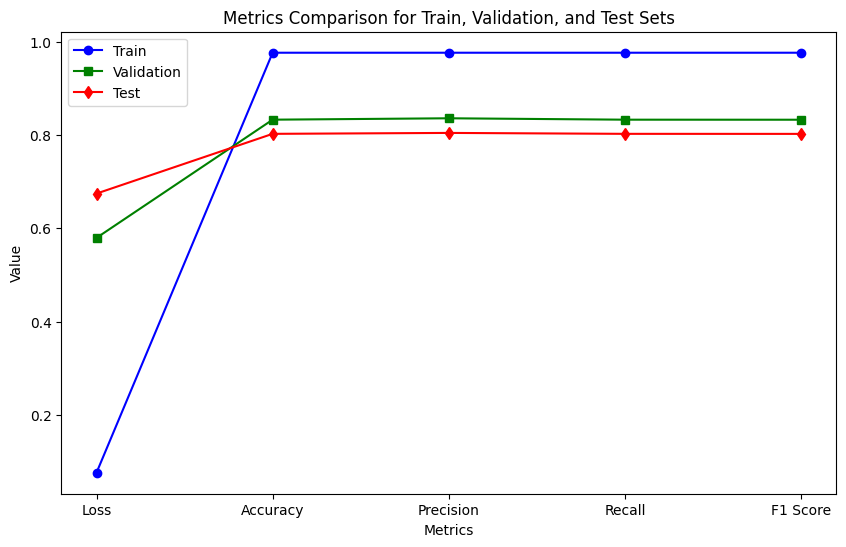

In [ ]:
import matplotlib.pyplot as plt

# Example data for each set (replace with your actual values)
train_metrics = {
    'Loss': 0.0761,
    'Accuracy': 0.9762,
    'Precision': 0.9762,
    'Recall': 0.9762,
    'F1 Score': 0.9762
}

val_metrics = {
    'Loss': 0.5794,
    'Accuracy': 0.8327,
    'Precision': 0.8357,
    'Recall': 0.8327,
    'F1 Score': 0.8326
}

test_metrics = {
    'Loss': test_loss,
    'Accuracy': test_accuracy,
    'Precision': test_precision,
    'Recall': test_recall,
    'F1 Score': test_f1
}

# Metrics to plot
metrics = ['Loss', 'Accuracy', 'Precision', 'Recall', 'F1 Score']

# Grouped metrics for plotting
train_values = [train_metrics[metric] for metric in metrics]
val_values = [val_metrics[metric] for metric in metrics]
test_values = [test_metrics[metric] for metric in metrics]

# Plotting
plt.figure(figsize=(10, 6))

x = range(len(metrics))  # X axis

plt.plot(x, train_values, label='Train', marker='o', color='b')
plt.plot(x, val_values, label='Validation', marker='s', color='g')
plt.plot(x, test_values, label='Test', marker='d', color='r')

# Customizing the plot
plt.xticks(x, metrics)
plt.xlabel('Metrics')
plt.ylabel('Value')
plt.title('Metrics Comparison for Train, Validation, and Test Sets')
plt.legend()

# Specify the directory and filename to save the image
save_dir = '/content/drive/MyDrive/hateful_memes/Results'
filename = 'metrics_comparison.png'
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

# Save the plot to the directory
plt.savefig(os.path.join(save_dir, filename))

# Display the plot
plt.show()